#MultiClass Classification

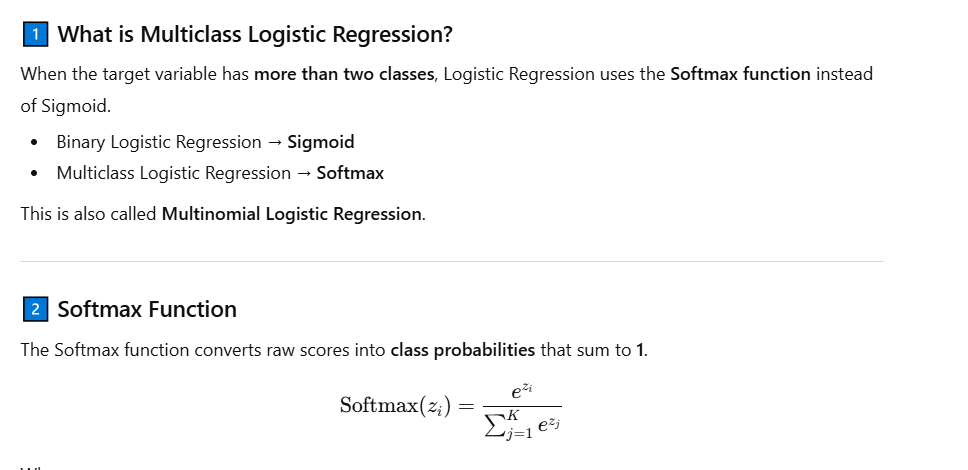

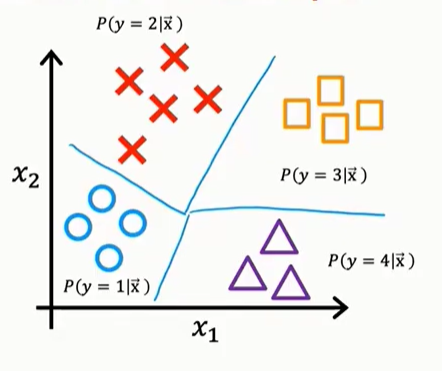

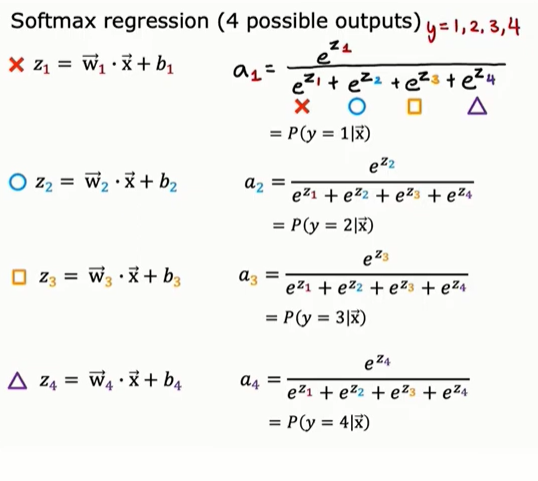

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report


In [ ]:
df=pd.read_csv("/content/iris.csv")

In [ ]:
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


sepal length (cm)

ده طول الـ sepal (السبلات) بالسنتيمتر.

الـ sepal هو الجزء الأخضر اللي بيكون حوالين الزهرة وهي لسه bud.
بيدينا فكرة عن حجم الزهرة من برّه.


2. sepal width (cm)

ده عرض الـ sepal.

بيقيس مدى اتساع الجزء الخارجي من الزهرة.



petal length (cm)

ده طول الـ petal (بتلات الزهرة).

الـ petal هو الجزء الداخلي الملون من الزهرة.
ده أهم feature تقريبًا في التمييز بين الأنواع.




petal width (cm)

ده عرض الـ petal.

بيكمل معلومات شكل البتلة.



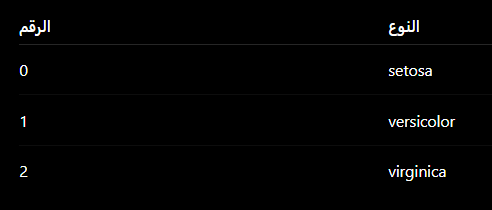

In [ ]:
df.columns

Index(['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)',
       'petal width (cm)', 'target'],
      dtype='object')

In [ ]:
x=df.drop("target",axis=1)
y=df["target"]

In [ ]:
x

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [ ]:
y

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [ ]:
print(y.value_counts())

target
0    50
1    50
2    50
Name: count, dtype: int64


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    x, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
#
y_test.shape

(30,)

In [ ]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
model = LogisticRegression(
    multi_class='multinomial',
    max_iter=1000
)

model.fit(X_train_scaled, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial')

In [ ]:
y_pred = model.predict(X_test_scaled)

In [ ]:
y_pred

array([0, 2, 1, 1, 0, 1, 0, 0, 2, 1, 2, 2, 2, 1, 0, 0, 0, 1, 1, 2, 0, 2,
       1, 1, 2, 2, 1, 0, 2, 0])

In [ ]:
y_prob = model.predict_proba(X_test_scaled)

print(y_prob[:2])


[[9.78818005e-01 2.11816311e-02 3.63821812e-07]
 [3.79836951e-03 3.69220168e-01 6.26981463e-01]]


In [ ]:
np.argmax([9.78818005e-01 ,2.11816311e-02 ,3.63821812e-07])

np.int64(0)

In [ ]:
np.argmax([[3.79836951e-03, 3.69220168e-01, 6.26981463e-01]])

np.int64(2)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9333333333333333
